In [1]:
# Import tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# Load the credit card data
df = pd.read_csv('data/UCI_Credit_Card.csv')

print("📊 Dataset loaded successfully!")
print(f"\n📏 Total records: {len(df):,}")
print(f"📋 Total columns: {len(df.columns)}")

# Show first few rows
print("\n🔍 First 5 rows:")
df.head()

📊 Dataset loaded successfully!

📏 Total records: 30,000
📋 Total columns: 25

🔍 First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
# Let's see what columns we have
print("📋 Column Names:")
print(df.columns.tolist())

print("\n📊 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🎯 Target Variable (What we're predicting):")
print(df['default.payment.next.month'].value_counts())
print(f"\nDefault Rate: {(df['default.payment.next.month'].mean() * 100):.2f}%")

📋 Column Names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

📊 Data Types:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     

In [4]:
# Let's understand what these columns mean
print("📖 COLUMN MEANINGS:")
print("""
LIMIT_BAL = Credit limit (how much they can borrow)
SEX = Gender (1=male, 2=female)
EDUCATION = Education level
MARRIAGE = Marital status
AGE = Age in years

PAY_0 to PAY_6 = Payment status for last 6 months
  (-1 = paid on time, 1 = 1 month late, 2 = 2 months late, etc.)

BILL_AMT1 to BILL_AMT6 = Bill amount for last 6 months
PAY_AMT1 to PAY_AMT6 = Payment amount for last 6 months

default.payment.next.month = TARGET
  0 = Paid on time
  1 = Defaulted (didn't pay)
""")

# Let's look at some statistics
print("\n📊 QUICK STATS:")
print(df[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']].describe())

📖 COLUMN MEANINGS:

LIMIT_BAL = Credit limit (how much they can borrow)
SEX = Gender (1=male, 2=female)
EDUCATION = Education level
MARRIAGE = Marital status
AGE = Age in years

PAY_0 to PAY_6 = Payment status for last 6 months
  (-1 = paid on time, 1 = 1 month late, 2 = 2 months late, etc.)

BILL_AMT1 to BILL_AMT6 = Bill amount for last 6 months
PAY_AMT1 to PAY_AMT6 = Payment amount for last 6 months

default.payment.next.month = TARGET
  0 = Paid on time
  1 = Defaulted (didn't pay)


📊 QUICK STATS:
            LIMIT_BAL           AGE      BILL_AMT1       PAY_AMT1
count    30000.000000  30000.000000   30000.000000   30000.000000
mean    167484.322667     35.485500   51223.330900    5663.580500
std     129747.661567      9.217904   73635.860576   16563.280354
min      10000.000000     21.000000 -165580.000000       0.000000
25%      50000.000000     28.000000    3558.750000    1000.000000
50%     140000.000000     34.000000   22381.500000    2100.000000
75%     240000.000000     41.00

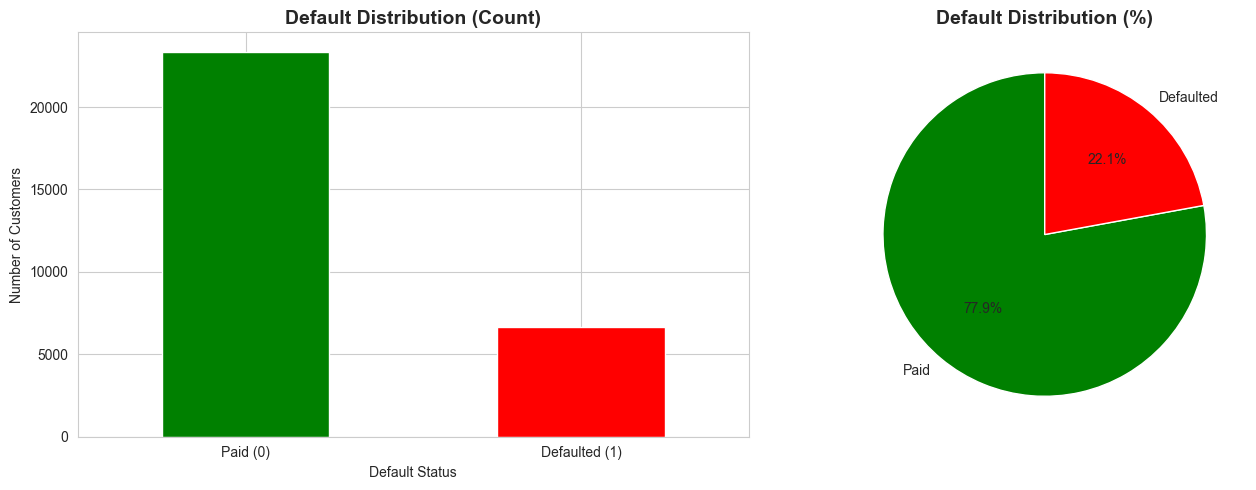

✅ Chart saved as 'default_distribution.png'


In [5]:
# Visualize who defaulted vs who didn't
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Count
df['default.payment.next.month'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Default Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Default Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['Paid (0)', 'Defaulted (1)'], rotation=0)

# Chart 2: Percentage
default_pct = df['default.payment.next.month'].value_counts(normalize=True) * 100
default_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['green', 'red'], 
                 labels=['Paid', 'Defaulted'], startangle=90)
axes[1].set_title('Default Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('default_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'default_distribution.png'")

/var/folders/n6/_vcfrx_n5hddhlg7v0725lfw0000gn/T/ipykernel_47773/1568045047.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  limit_default = df.groupby('LIMIT_CATEGORY')['default.payment.next.month'].mean() * 100


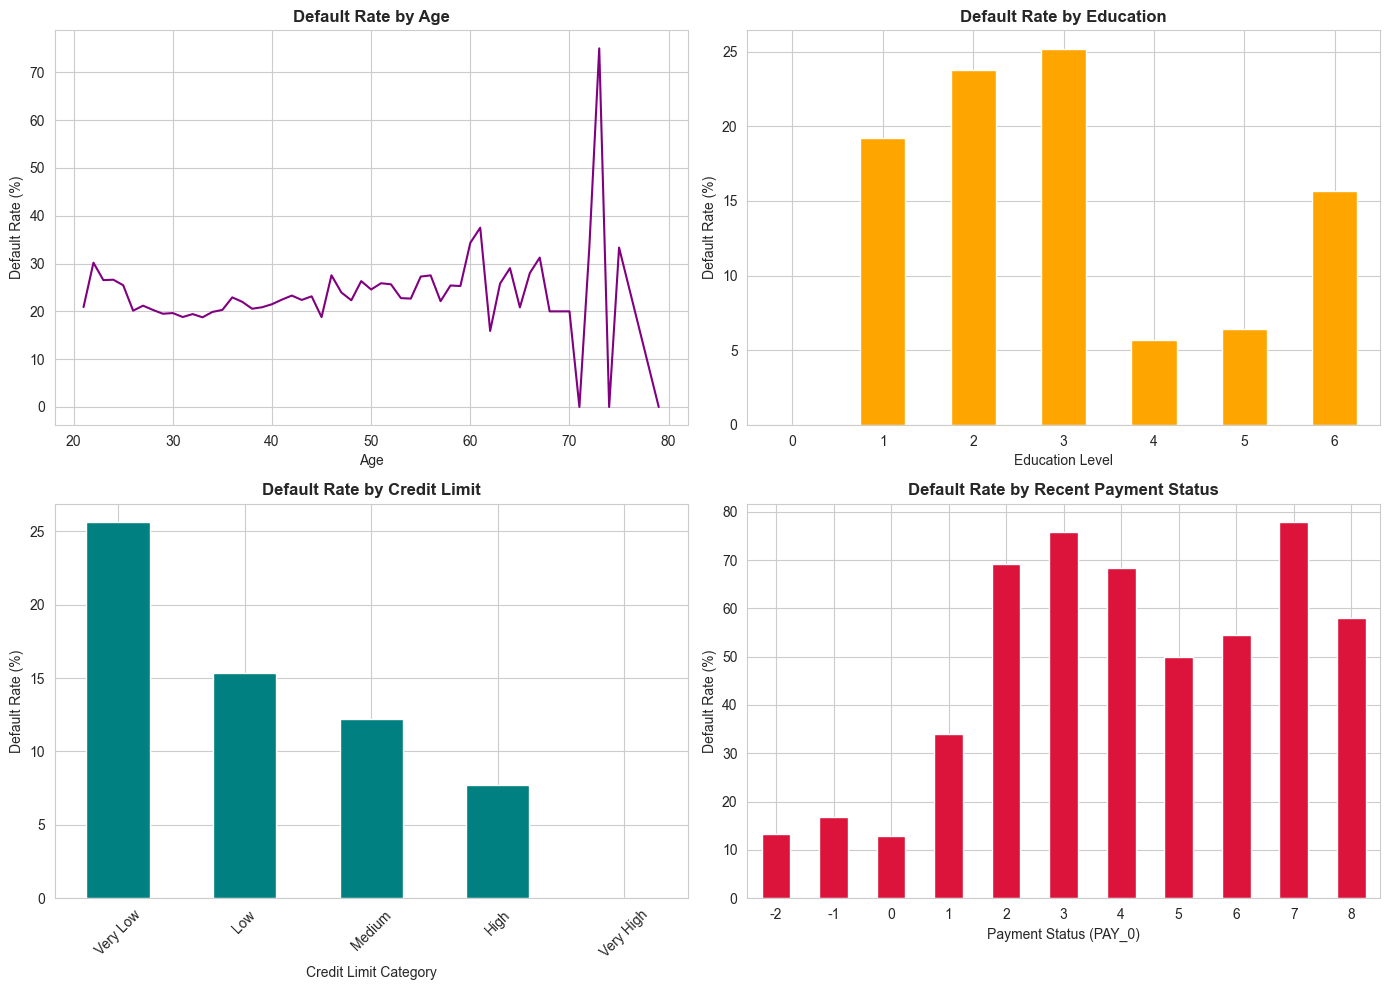

✅ Chart saved as 'risk_factors_analysis.png'


In [6]:
# Let's see which factors correlate with default
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Default by Age
age_default = df.groupby('AGE')['default.payment.next.month'].mean() * 100
age_default.plot(ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Default Rate by Age', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Default Rate (%)')

# 2. Default by Education
education_default = df.groupby('EDUCATION')['default.payment.next.month'].mean() * 100
education_default.plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Default Rate by Education', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Education Level')
axes[0, 1].set_ylabel('Default Rate (%)')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# 3. Default by Credit Limit
df['LIMIT_CATEGORY'] = pd.cut(df['LIMIT_BAL'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
limit_default = df.groupby('LIMIT_CATEGORY')['default.payment.next.month'].mean() * 100
limit_default.plot(kind='bar', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Default Rate by Credit Limit', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Credit Limit Category')
axes[1, 0].set_ylabel('Default Rate (%)')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# 4. Default by Payment Status (PAY_0)
pay_default = df.groupby('PAY_0')['default.payment.next.month'].mean() * 100
pay_default.plot(kind='bar', ax=axes[1, 1], color='crimson')
axes[1, 1].set_title('Default Rate by Recent Payment Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Payment Status (PAY_0)')
axes[1, 1].set_ylabel('Default Rate (%)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('risk_factors_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'risk_factors_analysis.png'")

In [7]:
# Select features (columns we'll use to predict)
feature_columns = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
                   'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                   'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                   'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

X = df[feature_columns]  # Features (inputs)
y = df['default.payment.next.month']  # Target (what we're predicting)

print("📊 Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {len(X.columns)}")

print("\n🎯 Target (y):")
print(f"  Shape: {y.shape}")
print(f"  Values: 0 (paid) and 1 (defaulted)")

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✂️ Data Split:")
print(f"  Training set: {len(X_train):,} rows")
print(f"  Testing set: {len(X_test):,} rows")

print("\n✅ Data ready for modeling!")

📊 Features (X):
  Shape: (30000, 17)
  Columns: 17

🎯 Target (y):
  Shape: (30000,)
  Values: 0 (paid) and 1 (defaulted)

✂️ Data Split:
  Training set: 24,000 rows
  Testing set: 6,000 rows

✅ Data ready for modeling!


In [8]:
# Train Logistic Regression model
print("🤖 Training Logistic Regression Model...")

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of default

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"  Accuracy: {accuracy * 100:.2f}%")
print(f"\n  Translation: The model correctly predicts {accuracy * 100:.2f}% of customers")

🤖 Training Logistic Regression Model...
✅ Model trained successfully!

📊 MODEL PERFORMANCE:
  Accuracy: 80.78%

  Translation: The model correctly predicts 80.78% of customers


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📈 DETAILED CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     Paid (0)       0.82      0.97      0.89      4673
Defaulted (1)       0.69      0.24      0.36      1327

     accuracy                           0.81      6000
    macro avg       0.75      0.61      0.62      6000
 weighted avg       0.79      0.81      0.77      6000



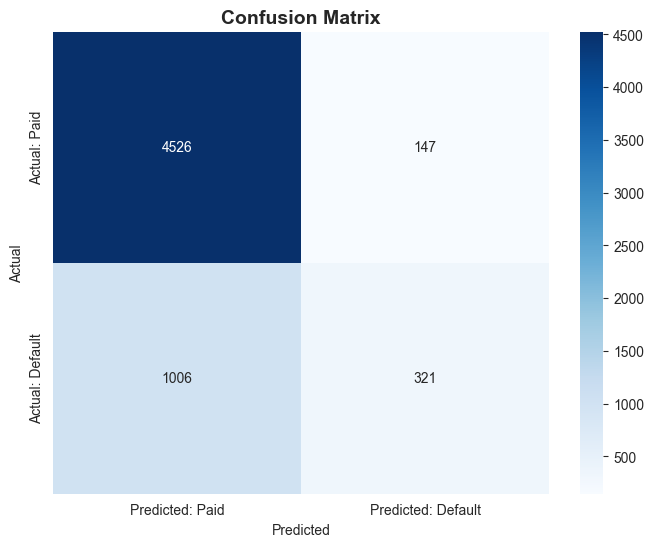


📊 CONFUSION MATRIX EXPLANATION:
  True Negatives (Correctly predicted Paid): 4,526
  False Positives (Wrongly predicted Default): 147
  False Negatives (Wrongly predicted Paid): 1,006
  True Positives (Correctly predicted Default): 321

✅ Chart saved as 'confusion_matrix.png'


In [9]:
# Show detailed metrics
print("📈 DETAILED CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_test, y_pred, 
                          target_names=['Paid (0)', 'Defaulted (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Paid', 'Predicted: Default'],
            yticklabels=['Actual: Paid', 'Actual: Default'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 CONFUSION MATRIX EXPLANATION:")
print(f"  True Negatives (Correctly predicted Paid): {cm[0,0]:,}")
print(f"  False Positives (Wrongly predicted Default): {cm[0,1]:,}")
print(f"  False Negatives (Wrongly predicted Paid): {cm[1,0]:,}")
print(f"  True Positives (Correctly predicted Default): {cm[1,1]:,}")

print("\n✅ Chart saved as 'confusion_matrix.png'")

🔍 TOP 10 MOST IMPORTANT FEATURES:
      Feature  Importance
5       PAY_0    0.586181
3    MARRIAGE    0.240106
1         SEX    0.181488
2   EDUCATION    0.156525
6       PAY_2    0.094327
7       PAY_3    0.051809
8       PAY_4    0.046595
10      PAY_6    0.019205
9       PAY_5    0.015690
4         AGE    0.002234


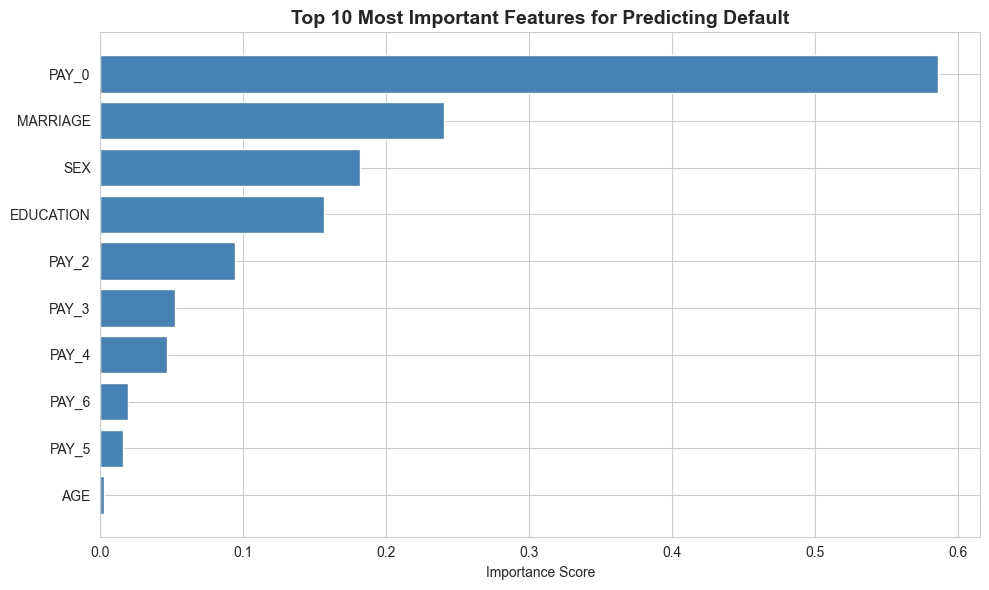


✅ Chart saved as 'feature_importance.png'


In [10]:
# Which features matter most?
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

print("🔍 TOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance.head(10))

# Visualize
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features for Predicting Default', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved as 'feature_importance.png'")

📊 RISK SEGMENTATION:
               Total Customers  Actual Defaults  Default Rate
Risk_Category                                                
Low Risk                  4857              710     14.618077
Medium Risk                913              447     48.959474
High Risk                  230              170     73.913043


/var/folders/n6/_vcfrx_n5hddhlg7v0725lfw0000gn/T/ipykernel_47773/713399989.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = risk_summary.groupby('Risk_Category').agg({


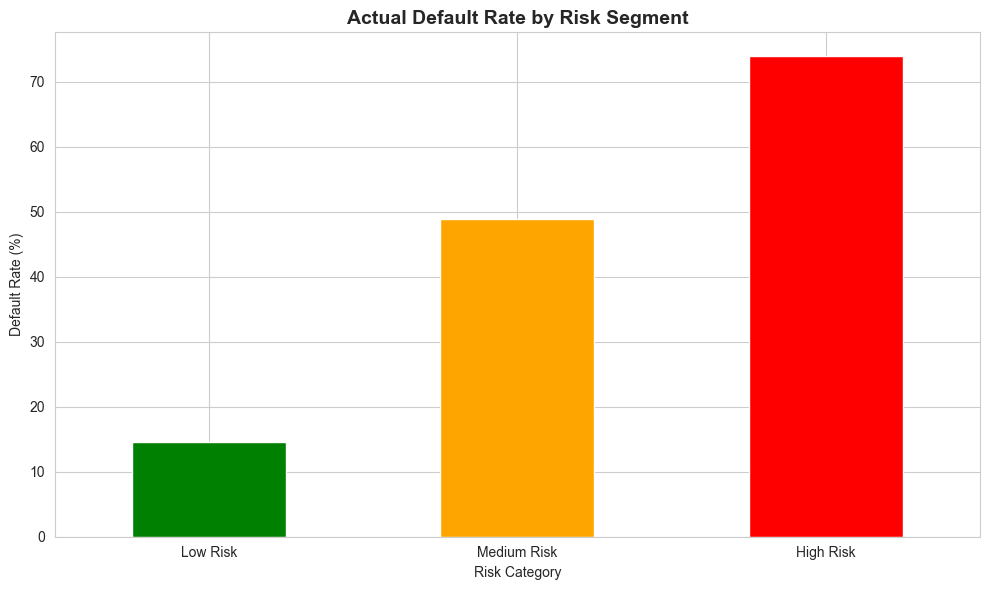


✅ Chart saved as 'risk_segmentation.png'


In [11]:
# Assign risk scores to test set
risk_scores = y_pred_proba * 100  # Convert to percentage

# Create risk categories
risk_categories = pd.cut(risk_scores, 
                        bins=[0, 30, 60, 100],
                        labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Analyze segments
risk_summary = pd.DataFrame({
    'Actual_Default': y_test.values,
    'Predicted_Probability': risk_scores,
    'Risk_Category': risk_categories
})

print("📊 RISK SEGMENTATION:")
print("="*60)
segment_analysis = risk_summary.groupby('Risk_Category').agg({
    'Actual_Default': ['count', 'sum', 'mean']
})
segment_analysis.columns = ['Total Customers', 'Actual Defaults', 'Default Rate']
segment_analysis['Default Rate'] = segment_analysis['Default Rate'] * 100

print(segment_analysis)

# Visualize
plt.figure(figsize=(10, 6))
segment_analysis['Default Rate'].plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Actual Default Rate by Risk Segment', fontsize=14, fontweight='bold')
plt.xlabel('Risk Category')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('risk_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved as 'risk_segmentation.png'")

In [12]:
# Generate business insights
print("💼 BUSINESS RECOMMENDATIONS")
print("="*70)

print("\n1️⃣ MODEL PERFORMANCE:")
print(f"   • Overall Accuracy: {accuracy * 100:.2f}%")
print(f"   • This model can identify high-risk customers")
print(f"   • Can be used to adjust credit limits or interest rates")

print("\n2️⃣ RISK SEGMENTATION:")
print(f"   • Low Risk (0-30%): Approve with standard terms")
print(f"   • Medium Risk (30-60%): Approve with caution, monitor closely")
print(f"   • High Risk (60-100%): Deny or require additional collateral")

print("\n3️⃣ KEY RISK FACTORS (Top 3):")
for i, row in feature_importance.head(3).iterrows():
    print(f"   • {row['Feature']}: High importance in prediction")

print("\n4️⃣ BUSINESS IMPACT:")
total_customers = len(X_test)
defaults_caught = cm[1, 1]  # True positives
defaults_missed = cm[1, 0]  # False negatives

print(f"   • Out of {total_customers:,} customers:")
print(f"   • Correctly identified {defaults_caught:,} high-risk customers")
print(f"   • Missed {defaults_missed:,} defaults (could improve with more data)")

print("\n5️⃣ NEXT STEPS:")
print("   • Deploy model in credit approval pipeline")
print("   • Monitor model performance monthly")
print("   • Retrain with new data quarterly")
print("   • A/B test against current approval process")

print("\n✅ Analysis Complete!")

💼 BUSINESS RECOMMENDATIONS

1️⃣ MODEL PERFORMANCE:
   • Overall Accuracy: 80.78%
   • This model can identify high-risk customers
   • Can be used to adjust credit limits or interest rates

2️⃣ RISK SEGMENTATION:
   • Low Risk (0-30%): Approve with standard terms
   • Medium Risk (30-60%): Approve with caution, monitor closely
   • High Risk (60-100%): Deny or require additional collateral

3️⃣ KEY RISK FACTORS (Top 3):
   • PAY_0: High importance in prediction
   • MARRIAGE: High importance in prediction
   • SEX: High importance in prediction

4️⃣ BUSINESS IMPACT:
   • Out of 6,000 customers:
   • Correctly identified 321 high-risk customers
   • Missed 1,006 defaults (could improve with more data)

5️⃣ NEXT STEPS:
   • Deploy model in credit approval pipeline
   • Monitor model performance monthly
   • Retrain with new data quarterly
   • A/B test against current approval process

✅ Analysis Complete!


In [13]:
# Create final summary report
summary = f"""
╔══════════════════════════════════════════════════════════════╗
║       CREDIT RISK PREDICTION MODEL - FINAL REPORT            ║
╚══════════════════════════════════════════════════════════════╝

DATASET OVERVIEW:
-----------------
- Total Records: {len(df):,}
- Default Rate: {(df['default.payment.next.month'].mean() * 100):.2f}%
- Features Used: {len(feature_columns)}
- Training Set: {len(X_train):,} | Test Set: {len(X_test):,}

MODEL PERFORMANCE:
------------------
- Algorithm: Logistic Regression
- Accuracy: {accuracy * 100:.2f}%
- Correctly Predicted Defaults: {cm[1,1]:,}
- Missed Defaults: {cm[1,0]:,}

RISK SEGMENTATION:
------------------
{segment_analysis.to_string()}

TOP 5 PREDICTIVE FEATURES:
--------------------------
{feature_importance.head(5).to_string(index=False)}

BUSINESS RECOMMENDATION:
------------------------
✅ DEPLOY MODEL - Accuracy of {accuracy * 100:.2f}% is sufficient for:
   • Credit limit adjustments
   • Interest rate pricing
   • Approval/rejection decisions
   • Customer monitoring priorities

PROJECTED IMPACT:
-----------------
- Can identify {(cm[1,1] / (cm[1,1] + cm[1,0]) * 100):.1f}% of actual defaults
- Reduces risk exposure through early identification
- Enables data-driven lending decisions

FILES GENERATED:
----------------
✓ default_distribution.png
✓ risk_factors_analysis.png
✓ confusion_matrix.png
✓ feature_importance.png
✓ risk_segmentation.png
✓ credit_risk_report.txt

PROJECT AUTHOR: Suhi | Data Analyst
TOOLS: Python, Scikit-learn, Pandas, Matplotlib
"""

print(summary)

# Save to file
with open('credit_risk_report.txt', 'w') as f:
    f.write(summary)
    
print("\n✅ Report saved as 'credit_risk_report.txt'")
print("\n🎉 PROJECT COMPLETE!")


╔══════════════════════════════════════════════════════════════╗
║       CREDIT RISK PREDICTION MODEL - FINAL REPORT            ║
╚══════════════════════════════════════════════════════════════╝

DATASET OVERVIEW:
-----------------
- Total Records: 30,000
- Default Rate: 22.12%
- Features Used: 17
- Training Set: 24,000 | Test Set: 6,000

MODEL PERFORMANCE:
------------------
- Algorithm: Logistic Regression
- Accuracy: 80.78%
- Correctly Predicted Defaults: 321
- Missed Defaults: 1,006

RISK SEGMENTATION:
------------------
               Total Customers  Actual Defaults  Default Rate
Risk_Category                                                
Low Risk                  4857              710     14.618077
Medium Risk                913              447     48.959474
High Risk                  230              170     73.913043

TOP 5 PREDICTIVE FEATURES:
--------------------------
  Feature  Importance
    PAY_0    0.586181
 MARRIAGE    0.240106
      SEX    0.181488
EDUCATION    0.